In [56]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy import stats
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
from itertools import combinations
import json
import random
from adjustText import adjust_text
import gget

sc.settings.verbosity = 2

# Load in TF-associated networks

In [2]:
# MYOD1
path1 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/MYOD_network_1storder_300.csv"
mdf = pd.read_csv(path1, index_col=0)
print(mdf.shape)
display(mdf.head())


# PRRX1
path2 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/PRRX1_network_1storder_300.csv"
pdf = pd.read_csv(path2, index_col=0)
print(pdf.shape)
display(pdf.head())

(545, 545)


,MYOD1,CD99,KDM1A,PDK4,CALCR,HOXA11,MEOX1,CREBBP,SOX8,IFRD1,...,INS,ENSG00000255071,EID1,SCX,DUX4,PECAM1,MYMX,MYH4,H3-7,DACH1
MYOD1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
CD99,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
KDM1A,1,0,1,1,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
PDK4,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
CALCR,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


(196, 196)


,PRRX1,COPZ2,TFAP2B,METTL13,DCN,SNAI2,VIM,CD44,CDH1,PHF23,...,COL5A2,POU5F1,VGLL3,EBF2,TWIST2,BGLAP,FOXD1,HOXB7,SCX,GTF2I
PRRX1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
COPZ2,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
TFAP2B,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
METTL13,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DCN,1,0,0,0,0,1,1,1,1,0,...,1,0,0,0,0,1,0,0,1,0


## Make graphs

In [3]:
# MYOD1
GM = nx.from_pandas_adjacency(mdf, create_using=nx.Graph) # keeps self-loops
GM.remove_edges_from(nx.selfloop_edges(GM)) # remove self-loops

print(f"MYOD1:\nN nodes: {GM.number_of_nodes()}\nN edges: {GM.number_of_edges()}")

n_edges = GM.number_of_edges()
n_nodes = GM.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

print(f'\nIs connected? {nx.is_connected(GM)}')
print(f'N connected components: {nx.number_connected_components(GM)}')
print(f'Largest connected components has {len(max(nx.connected_components(GM), key=len))} nodes\n')



# PRRX1
GP = nx.from_pandas_adjacency(pdf, create_using=nx.Graph) # keeps self-loops
GP.remove_edges_from(nx.selfloop_edges(GP)) # remove self-loops

print(f"\nPRRX1:\nN nodes: {GP.number_of_nodes()}\nN edges: {GP.number_of_edges()}")

n_edges = GP.number_of_edges()
n_nodes = GP.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

print(f'\nIs connected? {nx.is_connected(GP)}')
print(f'N connected components: {nx.number_connected_components(GP)}')
print(f'Largest connected components has {len(max(nx.connected_components(GP), key=len))} nodes')



## get gene lists for 1st order genes
myod_nodes = list(GM.nodes())
prrx_nodes = list(GP.nodes())

MYOD1:
N nodes: 545
N edges: 29898
Graph density: 0.2017

Is connected? True
N connected components: 1
Largest connected components has 545 nodes


PRRX1:
N nodes: 196
N edges: 4055
Graph density: 0.2122

Is connected? True
N connected components: 1
Largest connected components has 196 nodes


In [4]:
## get gene lists for 1st order genes
myod_nodes = list(GM.nodes())
print(len(myod_nodes))

prrx_nodes = list(GP.nodes())
print(len(prrx_nodes))

545
196


# Load in adata

In [5]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.43 GB, difference +2.43 GB
CPU times: user 571 ms, sys: 1.92 s, total: 2.49 s
Wall time: 5.44 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [6]:
# Load TFs
fpath = "../../resources/HumanTF_v_1.01.csv"

tdf = pd.read_csv(fpath)

tdf = tdf[['HGNC symbol', 'Is TF?']]
tdf = tdf.rename(columns={'HGNC symbol': 'gene_name', 'Is TF?': 'is_tf'})
tdf = tdf[tdf['is_tf'] == 'Yes']
tdf = tdf.drop_duplicates(subset='gene_name')
display(tdf.head())

# extract unique TFs
tf_list = tdf['gene_name'].unique()
print(len(tf_list))

tf_list = [g for g in tf_list if g in adata.var_names]

print(len(tf_list))

,gene_name,is_tf
0,TFAP2A,Yes
1,TFAP2B,Yes
2,TFAP2C,Yes
3,TFAP2D,Yes
4,TFAP2E,Yes


1639
1358


In [7]:
conditions_to_keep = ['Control', 'mmMYOD1', 'siPRRX1/mmMYOD1']

fdata = adata[adata.obs['pooled_condition'].isin(conditions_to_keep), :].copy()
print(fdata.shape)

(12613, 25126)


In [8]:
# filter genes
fdata.X = fdata.layers['raw_counts'].copy()

sc.pp.filter_genes(fdata, min_counts=10) # param used for original processing

sc.pp.normalize_total(fdata, target_sum=1e4)
fdata.layers['CP10K'] = fdata.X.copy()

sc.pp.log1p(fdata)
fdata.layers['log_norm_new'] = fdata.X.copy()
fdata

filtered out 583 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 12613 × 24543
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Detected genes

In [9]:
### Which genes are present in adata?
# MYOD1
gene_names = set(fdata.var_names)
gene_ids = set(fdata.var['gene_id'])

myod_genes = [
    g for g in myod_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_myod_genes = list(set(myod_nodes) - set(myod_genes))

print(f"N myod nodes in fdata: {len(myod_genes)}")
print(f"{len(missing_myod_genes)} genes not detected.\n")


# PRRX1
prrx_genes = [
    g for g in prrx_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_prrx_genes = list(set(prrx_nodes) - set(prrx_genes))

print(f"N prrx1 nodes in fdata: {len(prrx_genes)}")
print(f"{len(missing_prrx_genes)} genes not detected.")

N myod nodes in fdata: 443
102 genes not detected.

N prrx1 nodes in fdata: 179
17 genes not detected.


In [10]:
### genes expressed in greater than 10% of cells in either condition
pct_exp_thresh = 0.10

print(f"Nodes (genes) expressed in ≥ {pct_exp_thresh*100:.0f}% of cells in either condition...")

## --------- MYOD1 genes ---------
# Boolean matrix: cells × genes
fdata.X = fdata.layers['raw_counts'].copy()

X = fdata[:, myod_genes].X > 0

# Convert to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

df = pd.DataFrame(X, index=fdata.obs['pooled_condition'], columns=myod_genes)

# Compute fraction per condition
frac_by_condition = df.groupby(level=0, observed=True).mean()

# Keep genes passing threshold in ANY condition
myod_genes_robust = frac_by_condition.columns[(frac_by_condition >= pct_exp_thresh).any(axis=0)].tolist()
print(f"\nN MYOD1 genes: {len(myod_genes_robust)}")
print(f"% of detected nodes: {(len(myod_genes_robust) / len(myod_genes))*100:.1f}%")
print(f"% of total nodes: {(len(myod_genes_robust) / len(myod_nodes))*100:.1f}%")


## --------- PRRX1 genes ---------
X = fdata[:, prrx_genes].X > 0

# Convert to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

df = pd.DataFrame(X, index=fdata.obs['pooled_condition'], columns=prrx_genes)

# Compute fraction per condition
frac_by_condition = df.groupby(level=0, observed=True).mean()

# Keep genes passing threshold in ANY condition
prrx_genes_robust = frac_by_condition.columns[(frac_by_condition >= pct_exp_thresh).any(axis=0)].tolist()
print(f"\nN PRRX1 genes: {len(prrx_genes_robust)}")
print(f"% of detected nodes: {(len(prrx_genes_robust) / len(prrx_genes))*100:.1f}%")
print(f"% of total nodes: {(len(prrx_genes_robust) / len(prrx_nodes))*100:.1f}%")

Nodes (genes) expressed in ≥ 10% of cells in either condition...

N MYOD1 genes: 269
% of detected nodes: 60.7%
% of total nodes: 49.4%

N PRRX1 genes: 128
% of detected nodes: 71.5%
% of total nodes: 65.3%


# Build baseline subgraphs

In [11]:
# Baseline
print("Baseline subgraphs...")

BGM = GM.subgraph(myod_genes_robust).copy()
n_edges = BGM.number_of_edges()
n_nodes = BGM.number_of_nodes()
print(f"\nMYOD1 - N nodes: {n_nodes}, N edges: {n_edges}")
density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")
print(f'Is connected? {nx.is_connected(BGM)}')
print(f'N connected components: {nx.number_connected_components(BGM)}')
print(f'Largest connected components has {len(max(nx.connected_components(BGM), key=len))} nodes')


BGP = GP.subgraph(prrx_genes_robust).copy()
n_edges = BGP.number_of_edges()
n_nodes = BGP.number_of_nodes()
print(f"\nPRRX1 - N nodes: {n_nodes}, N edges: {n_edges}")
density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")
print(f'Is connected? {nx.is_connected(BGP)}')
print(f'N connected components: {nx.number_connected_components(BGP)}')
print(f'Largest connected components has {len(max(nx.connected_components(BGP), key=len))} nodes')

Baseline subgraphs...

MYOD1 - N nodes: 269, N edges: 9749
Graph density: 0.2705
Is connected? True
N connected components: 1
Largest connected components has 269 nodes

PRRX1 - N nodes: 128, N edges: 2095
Graph density: 0.2578
Is connected? True
N connected components: 1
Largest connected components has 128 nodes


In [12]:
summary = pd.DataFrame({
    "nodes": [BGM.number_of_nodes(), BGP.number_of_nodes()],
    "edges": [BGM.number_of_edges(), BGP.number_of_edges()],
    "avg_degree": [
        sum(dict(BGM.degree()).values())/BGM.number_of_nodes(),
        sum(dict(BGP.degree()).values())/BGP.number_of_nodes()
    ],
    "avg_clustering": [
        nx.average_clustering(BGM),
        nx.average_clustering(BGP)
    ],
}, index=["MYOD1","PRRX1"])

print(summary)

       nodes  edges  avg_degree  avg_clustering
MYOD1    269   9749   72.483271        0.648806
PRRX1    128   2095   32.734375        0.673684


# PRRX1 network destabilization

## Pseudobulk expression

In [13]:
aggdata = sc.get.aggregate(
    fdata,
    by='pooled_condition',
    func='sum',
    layer='raw_counts',
)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
aggdata.layers['CP10K'] = aggdata.X.copy()

sc.pp.log1p(aggdata)
aggdata.layers['log_norm'] = aggdata.X.copy()

print(aggdata)

aggdata.X = aggdata.layers['log_norm'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

normalizing counts per cell
    finished (0:00:00)
AnnData object with n_obs × n_vars = 3 × 24543
    obs: 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'CP10K', 'log_norm'
(24543, 4)


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1
0,A1BG,0.556086,0.405699,0.375847
1,A1BG-AS1,0.040967,0.082219,0.075412
2,A1CF,0.000200,0.009700,0.007607
3,A2M,0.121196,0.013313,0.017090
4,A2M-AS1,0.002791,0.003244,0.002832


In [14]:
# filter for PRRX1 nodes
mdf = df[df['gene_name'].isin(BGP.nodes())]
print(mdf.shape)
mdf.head()

(128, 4)


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1
193,ACTA2,0.604842,0.202605,0.229439
218,ACVR1,0.157741,0.277346,0.233421
297,ADD3,0.426999,0.381590,0.402751
362,AEBP1,1.334156,0.327758,0.424393
737,AOPEP,0.398799,0.672990,0.567013


In [15]:
def pct_expressing_by_group(adata, group_key, genes, layer="raw_counts", threshold=0):
    # subset to genes of interest
    genes = [g for g in genes if g in adata.var_names]
    A = adata[:, genes].layers[layer]
    if not sp.issparse(A):
        A = sp.csr_matrix(A)

    groups = adata.obs[group_key].astype(str).values
    out = pd.DataFrame(index=genes)

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        sub = A[idx, :]
        pct = (sub > threshold).mean(axis=0)  # fraction expressing
        pct = np.asarray(pct).ravel()
        out[f"pct_expr_{g}"] = pct

    out.index.name = "gene_name"
    return out.reset_index()

# compute for PRRX1 network genes
pct_df = pct_expressing_by_group(
    fdata, group_key="pooled_condition", genes=list(BGP.nodes()), layer="raw_counts", threshold=0
)

mdf = mdf.merge(pct_df, on='gene_name', how='left')
print(mdf.shape)
mdf.head()

(128, 7)


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1
0,ACTA2,0.604842,0.202605,0.229439,0.371776,0.168958,0.237847
1,ACVR1,0.157741,0.277346,0.233421,0.216459,0.278492,0.265914
2,ADD3,0.426999,0.381590,0.402751,0.496957,0.333925,0.418403
3,AEBP1,1.334156,0.327758,0.424393,0.920892,0.274501,0.416667
4,AOPEP,0.398799,0.672990,0.567013,0.473486,0.587140,0.588542


In [16]:
# set expr to 0 for genes expressed in less than 10% of cells per group
conditions = ['Control', 'mmMYOD1', 'siPRRX1/mmMYOD1']
pct_prefix = 'pct_expr_'
min_pct = 0.10 # 10%

for cond in conditions:
    pct_col = f"{pct_prefix}{cond}"
    expr_col = cond
    mdf.loc[mdf[pct_col] < min_pct, expr_col] = 0
    
mdf.head()

,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1
0,ACTA2,0.604842,0.202605,0.229439,0.371776,0.168958,0.237847
1,ACVR1,0.157741,0.277346,0.233421,0.216459,0.278492,0.265914
2,ADD3,0.426999,0.381590,0.402751,0.496957,0.333925,0.418403
3,AEBP1,1.334156,0.327758,0.424393,0.920892,0.274501,0.416667
4,AOPEP,0.398799,0.672990,0.567013,0.473486,0.587140,0.588542


In [17]:
# How many expressed genes per condition?
for c in conditions:
    n_expressed = (mdf[c] != 0).sum()
    print(f"{c}: {n_expressed} expressed genes (non-zero)")

Control: 120 expressed genes (non-zero)
mmMYOD1: 120 expressed genes (non-zero)
siPRRX1/mmMYOD1: 121 expressed genes (non-zero)


In [18]:
mdf['is_tf'] = mdf['gene_name'].isin(tf_list)

mdf.head()

,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1,is_tf
0,ACTA2,0.604842,0.202605,0.229439,0.371776,0.168958,0.237847,False
1,ACVR1,0.157741,0.277346,0.233421,0.216459,0.278492,0.265914,False
2,ADD3,0.426999,0.381590,0.402751,0.496957,0.333925,0.418403,False
3,AEBP1,1.334156,0.327758,0.424393,0.920892,0.274501,0.416667,True
4,AOPEP,0.398799,0.672990,0.567013,0.473486,0.587140,0.588542,False


## Bin expression

In [19]:
# bin expression values
expr_cols = ["Control", "mmMYOD1", "siPRRX1/mmMYOD1"]
ref_col = 'Control'
tf_col = 'is_tf'
q_low = 1/3
q_high = 2/3 # tertiles -> low/med/high


# Control-only cutoffs, separately for TF vs non-TF
cutoffs = {}
for tf_flag, label in [(True, "tf"), (False, "non_tf")]:
    ref = mdf.loc[mdf[tf_col].eq(tf_flag), ref_col].astype(float)

    # learn cutoffs among expressed genes only
    ref_nz = ref[ref > 0]
    lo = ref_nz.quantile(q_low) if len(ref_nz) else 0.0
    hi = ref_nz.quantile(q_high) if len(ref_nz) else 0.0
    cutoffs[label] = (lo, hi)

def expr_bin_notexpr(x, lo, hi):
    x = x.astype(float)
    out = pd.Series(index=x.index, dtype="object")
    out.loc[x == 0] = "not expressed"
    out.loc[x > 0] = pd.cut(
        x.loc[x > 0],
        bins=[0, lo, hi, np.inf],
        labels=["low", "med", "high"],
        include_lowest=True
    ).astype(str)
    return out

# assign bins per condition using the Control-derived TF/non-TF cutoffs
for c in expr_cols:
    lo, hi = cutoffs["tf"]
    mdf.loc[mdf[tf_col].eq(True), f"expr_bin_{c}"] = expr_bin_notexpr(
        mdf.loc[mdf[tf_col].eq(True), c], lo, hi
    )

    lo, hi = cutoffs["non_tf"]
    mdf.loc[mdf[tf_col].eq(False), f"expr_bin_{c}"] = expr_bin_notexpr(
        mdf.loc[mdf[tf_col].eq(False), c], lo, hi
    )
    
print(mdf.shape)
mdf.head()

(128, 11)


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1,is_tf,expr_bin_Control,expr_bin_mmMYOD1,expr_bin_siPRRX1/mmMYOD1
0,ACTA2,0.604842,0.202605,0.229439,0.371776,0.168958,0.237847,False,med,low,low
1,ACVR1,0.157741,0.277346,0.233421,0.216459,0.278492,0.265914,False,low,low,low
2,ADD3,0.426999,0.381590,0.402751,0.496957,0.333925,0.418403,False,med,med,med
3,AEBP1,1.334156,0.327758,0.424393,0.920892,0.274501,0.416667,True,high,med,high
4,AOPEP,0.398799,0.672990,0.567013,0.473486,0.587140,0.588542,False,med,med,med


## Normalize expression

In [20]:
def robust_minmax_from_control_nonzero(mdf, expr_col, ref_col="Control", is_tf_col="is_tf",
                                       q_low=0.01, q_high=0.99, eps=1e-12):
    scaled = np.zeros(len(mdf), dtype=float)

    for tf_flag in [True, False]:
        mask = mdf[is_tf_col].eq(tf_flag).to_numpy()
        ref = mdf.loc[mask, ref_col].astype(float)

        ref_nz = ref[ref > 0]
        if len(ref_nz) == 0:
            # everything is zero in control for this group
            scaled[mask] = 0.0
            continue

        lo = ref_nz.quantile(q_low)
        hi = ref_nz.quantile(q_high)
        print(lo, hi)
        denom = (hi - lo) if hi > lo else 1.0

        x = mdf.loc[mask, expr_col].astype(float).to_numpy()

        s = (x - lo) / denom
        s[x <= 0] = 0.0                 # keep true zeros at 0
        scaled[mask] = np.clip(s, 0, 1)

    return scaled

mdf["a_Control"] = robust_minmax_from_control_nonzero(mdf, "Control")
mdf["a_mmMYOD1"] = robust_minmax_from_control_nonzero(mdf, "mmMYOD1")
mdf["a_siPRRX1/mmMYOD1"] = robust_minmax_from_control_nonzero(mdf, "siPRRX1/mmMYOD1")

mdf.head()

0.07680599248702895 1.3899372336640234
0.08384159112333989 3.7512863883945697
0.07680599248702895 1.3899372336640234
0.08384159112333989 3.7512863883945697
0.07680599248702895 1.3899372336640234
0.08384159112333989 3.7512863883945697


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1,is_tf,expr_bin_Control,expr_bin_mmMYOD1,expr_bin_siPRRX1/mmMYOD1,a_Control,a_mmMYOD1,a_siPRRX1/mmMYOD1
0,ACTA2,0.604842,0.202605,0.229439,0.371776,0.168958,0.237847,False,med,low,low,0.142061,0.032383,0.039700
1,ACVR1,0.157741,0.277346,0.233421,0.216459,0.278492,0.265914,False,low,low,low,0.020150,0.052763,0.040786
2,ADD3,0.426999,0.381590,0.402751,0.496957,0.333925,0.418403,False,med,med,med,0.093568,0.081187,0.086957
3,AEBP1,1.334156,0.327758,0.424393,0.920892,0.274501,0.416667,True,high,med,high,0.957520,0.191110,0.264701
4,AOPEP,0.398799,0.672990,0.567013,0.473486,0.587140,0.588542,False,med,med,med,0.085879,0.160643,0.131746


In [21]:
mdf[['a_Control', 'a_mmMYOD1', 'a_siPRRX1/mmMYOD1']].describe()

,a_Control,a_mmMYOD1,a_siPRRX1/mmMYOD1
count,128.000000,128.000000,128.000000
mean,0.203641,0.173968,0.159840
std,0.244988,0.203506,0.195509
min,0.000000,0.000000,0.000000
25%,0.029635,0.047630,0.031538
50%,0.098647,0.103324,0.088996
75%,0.289200,0.201132,0.200670
max,1.000000,1.000000,1.000000


In [22]:
# make node -> activity dicts
a_ctrl = dict(zip(mdf["gene_name"], mdf["a_Control"]))
a_mmy  = dict(zip(mdf["gene_name"], mdf["a_mmMYOD1"]))
a_hyb  = dict(zip(mdf["gene_name"], mdf["a_siPRRX1/mmMYOD1"]))

def add_edge_weights_from_node_activity(G, a, weight_attr="weight", combine="product"):
    Gw = G.copy()
    for u, v in Gw.edges():
        au = a.get(u, 0.0)
        av = a.get(v, 0.0)
        if combine == "product":
            w = au * av
        elif combine == "min":
            w = min(au, av)
        elif combine == "mean":
            w = 0.5 * (au + av)
        else:
            raise ValueError("combine must be 'product', 'min', or 'mean'")
        Gw[u][v][weight_attr] = float(w)
    return Gw

def edge_weight_series(G):
    return [d.get("weight", 0.0) for _, _, d in G.edges(data=True)]

# weighted graphs per condition
sub_GP_control = add_edge_weights_from_node_activity(BGP, a_ctrl, weight_attr="weight", combine="product")
sub_GP_mmMYOD1 = add_edge_weights_from_node_activity(BGP, a_mmy,  weight_attr="weight", combine="product")
sub_GP_HYB = add_edge_weights_from_node_activity(BGP, a_hyb,  weight_attr="weight", combine="product")


ctrl_sum = sum(edge_weight_series(sub_GP_control))
treat_sum1 = sum(edge_weight_series(sub_GP_mmMYOD1))
treat_sum2 = sum(edge_weight_series(sub_GP_HYB))

print("Sum edge weight (Control):", ctrl_sum)
print("\nSum edge weight (mmMYOD1):", treat_sum1)
print("Delta:", treat_sum1 - ctrl_sum)
print("\nSum edge weight (siPRRX1/mmMYOD1):", treat_sum2)
print("Delta:", treat_sum2 - ctrl_sum)

Sum edge weight (Control): 170.30727308701006

Sum edge weight (mmMYOD1): 93.51029811666606
Delta: -76.796974970344

Sum edge weight (siPRRX1/mmMYOD1): 78.52778374489482
Delta: -91.77948934211524


In [23]:
# print(f'Is connected? {nx.is_connected(sub_GP_control)}')
# print(f'N connected components: {nx.number_connected_components(sub_GP_control)}')
# print(f'Largest connected components has {len(max(nx.connected_components(sub_GP_control), key=len))} nodes')

# print(f'\nIs connected? {nx.is_connected(sub_GP_siPRRX1)}')
# print(f'N connected components: {nx.number_connected_components(sub_GP_siPRRX1)}')
# print(f'Largest connected components has {len(max(nx.connected_components(sub_GP_siPRRX1), key=len))} nodes')

Is connected? True
N connected components: 1
Largest connected components has 125 nodes

Is connected? True
N connected components: 1
Largest connected components has 125 nodes


In [23]:
def n_active_edges(G, weight="weight"):
    return sum(1 for _,_,d in G.edges(data=True) if d.get(weight, 0.0) > 0)

print("Active edges Control:", n_active_edges(sub_GP_control))
print("Active edges mmMYOD1:", n_active_edges(sub_GP_mmMYOD1))
print("Active edges siPRRX1/mmMYOD1:", n_active_edges(sub_GP_HYB))

# density of active edges
Md = (2 * n_active_edges(sub_GP_mmMYOD1)) / (sub_GP_mmMYOD1.number_of_nodes() * (sub_GP_mmMYOD1.number_of_nodes() - 1))
Hd = (2 * n_active_edges(sub_GP_HYB)) / (sub_GP_HYB.number_of_nodes() * (sub_GP_HYB.number_of_nodes() - 1))
Cd = (2 * n_active_edges(sub_GP_control)) / (sub_GP_control.number_of_nodes() * (sub_GP_control.number_of_nodes() - 1))

print(f"\nActive graph density Control: {Cd:.4f}")
print(f"Active graph density mmMYOD1: {Md:.4f}")
print(f"Active graph density siPRRX1/mmMYOD1: {Hd:.4f}")

Active edges Control: 1932
Active edges mmMYOD1: 1846
Active edges siPRRX1/mmMYOD1: 1914

Active graph density Control: 0.2377
Active graph density mmMYOD1: 0.2271
Active graph density siPRRX1/mmMYOD1: 0.2355


## Centrality

In [25]:
def active_eigenvector_centrality_df(G, weight="weight", zero_tol=0.0, label=None):
    """
    Computes eigenvector centrality on the largest connected component of the
    subgraph induced by edges with weight > zero_tol. Nodes not in that component
    (or with no active edges) get 0 centrality.

    Returns a DataFrame with columns:
      - gene_name
      - eigencent_{label}
      - strength_{label}   (weighted degree)
      - degree_{label}     (unweighted degree in the original G)
    """
    # Build active-edge subgraph (keep all nodes for alignment)
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from((u, v, d) for u, v, d in G.edges(data=True) if d.get(weight, 0.0) > zero_tol)

    # defaults
    ec = {n: 0.0 for n in G.nodes()}

    if H.number_of_edges() > 0:
        lcc_nodes = max(nx.connected_components(H), key=len)
        print(f"{label} largest connected component: {len(lcc_nodes)} nodes")
        H_lcc = H.subgraph(lcc_nodes).copy()
        ec_lcc = nx.eigenvector_centrality(H_lcc, weight=weight, max_iter=10_000)
        ec.update(ec_lcc)

    strength = dict(G.degree(weight=weight))  # weighted degree in original weighted graph
    degree = dict(G.degree())                # unweighted degree in original graph

    suffix = "" if label is None else f"_{label}"
    return pd.DataFrame({
        "gene_name": list(G.nodes()),
        f"eigencent{suffix}": [ec[n] for n in G.nodes()],
        f"strength{suffix}": [strength.get(n, 0.0) for n in G.nodes()],
        f"degree{suffix}":   [degree.get(n, 0) for n in G.nodes()],
    })

# Example usage
df_ctrl = active_eigenvector_centrality_df(sub_GP_control, weight="weight", zero_tol=0.0, label="Control")
df_mmy  = active_eigenvector_centrality_df(sub_GP_mmMYOD1,  weight="weight", zero_tol=0.0, label="mmMYOD1")
df_hyb  = active_eigenvector_centrality_df(sub_GP_HYB,  weight="weight", zero_tol=0.0, label="siPRRX1/mmMYOD1")

# Merge into one table and compute deltas
centrality_df = df_ctrl.merge(df_mmy, on="gene_name", how="outer")
centrality_df = centrality_df.merge(df_hyb, on='gene_name', how='outer')

centrality_df["delta_eigencent_hyb"] = centrality_df["eigencent_siPRRX1/mmMYOD1"] - centrality_df["eigencent_Control"]
centrality_df["delta_strength_hyb"]  = centrality_df["strength_siPRRX1/mmMYOD1"]  - centrality_df["strength_Control"]
centrality_df["delta_eigencent_mmy"] = centrality_df["eigencent_mmMYOD1"] - centrality_df["eigencent_Control"]
centrality_df["delta_strength_mmy"]  = centrality_df["strength_mmMYOD1"]  - centrality_df["strength_Control"]

centrality_df.head()

Control largest connected component: 118 nodes
mmMYOD1 largest connected component: 120 nodes
siPRRX1/mmMYOD1 largest connected component: 121 nodes


,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,eigencent_siPRRX1/mmMYOD1,strength_siPRRX1/mmMYOD1,degree_siPRRX1/mmMYOD1,delta_eigencent_hyb,delta_strength_hyb,delta_eigencent_mmy,delta_strength_mmy
0,ACTA2,0.046134,2.365200,55,0.013751,0.385528,55,0.019323,0.453574,55,-0.026811,-1.911626,-0.032383,-1.979672
1,ACVR1,0.001626,0.070952,18,0.006828,0.188123,18,0.004056,0.107786,18,0.002430,0.036834,0.005202,0.117171
2,ADD3,0.003195,0.219647,15,0.005563,0.219366,15,0.004395,0.188622,15,0.001200,-0.031024,0.002368,-0.000281
3,AEBP1,0.201658,9.674258,29,0.027231,0.965339,29,0.044586,1.353806,29,-0.157072,-8.320451,-0.174427,-8.708919
4,AOPEP,0.002894,0.147903,6,0.010492,0.280803,6,0.006436,0.194423,6,0.003542,0.046520,0.007599,0.132900


In [26]:
centrality_df[['delta_eigencent_hyb', 'delta_eigencent_mmy', 'delta_strength_hyb', 'delta_strength_mmy']].describe()

,delta_eigencent_hyb,delta_eigencent_mmy,delta_strength_hyb,delta_strength_mmy
count,128.000000,128.000000,128.000000,128.000000
mean,-0.003277,-0.001235,-1.434055,-1.199953
std,0.041045,0.049727,2.680067,2.674361
min,-0.162833,-0.174427,-14.808433,-12.352875
25%,-0.010023,-0.016795,-1.943842,-2.010930
50%,-0.000043,0.001577,-0.160677,-0.018267
75%,0.003899,0.009780,0.030781,0.126134
max,0.141584,0.191410,1.407837,5.058446


In [28]:
ptmp_cols = [col for col in centrality_df.columns if 'siPRRX1' in col]
mtmp_cols = [col for col in centrality_df.columns if '_mmMYOD1' in col]
ctmp_cols = [col for col in centrality_df.columns if 'Control' in col]

ctmp = centrality_df.drop(columns=mtmp_cols)
ctmp = ctmp.drop(columns=ptmp_cols)
print(ctmp.shape)

mtmp = centrality_df.drop(columns=ctmp_cols)
mtmp = mtmp.drop(columns=ptmp_cols)
mtmp = mtmp.sort_values(by='eigencent_mmMYOD1', ascending=False)
print(mtmp.shape)
display(mtmp.tail())

htmp = centrality_df.drop(columns=ctmp_cols)
htmp = htmp.drop(columns=mtmp_cols)
print(htmp.shape)


print(f"mmMYOD1:\nN genes with weighted degree = 0: {len(mtmp[mtmp['strength_mmMYOD1'] == 0.0])}")
print(f"Mean degree strength (with 0s): {mtmp['strength_mmMYOD1'].mean():.3f}")
print(f"Mean degree strength (no 0s): {mtmp['strength_mmMYOD1'].replace(0, np.nan).mean():.3f}")


print(f"\nsiPRRX1/mmMYOD1:\nN genes with weighted degree = 0: {len(htmp[htmp['strength_siPRRX1/mmMYOD1'] == 0.0])}")
print(f"Mean degree strength (with 0s): {htmp['strength_siPRRX1/mmMYOD1'].mean():.3f}")
print(f"Mean degree strength (no 0s): {htmp['strength_siPRRX1/mmMYOD1'].replace(0, np.nan).mean():.3f}")


print(f"\nControl:\nN genes with weighted degree = 0: {len(ctmp[ctmp['strength_Control'] == 0.0])}")
print(f"Mean degree strength (with 0s): {ctmp['strength_Control'].mean():.3f}")
print(f"Mean degree strength (no 0s): {ctmp['strength_Control'].replace(0, np.nan).mean():.3f}")

(128, 8)
(128, 8)


,gene_name,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,delta_eigencent_hyb,delta_strength_hyb,delta_eigencent_mmy,delta_strength_mmy
46,FOXM1,0.0,0.0,25,-0.001804,-0.240791,-0.004871,-0.327094
33,EFEMP1,0.0,0.0,31,-0.037656,-1.847290,-0.044061,-2.007296
41,FOXC1,0.0,0.0,32,-0.001545,-0.128788,-0.001545,-0.128788
42,FOXC2,0.0,0.0,29,0.001295,0.002440,-0.000738,-0.042480
90,POSTN,0.0,0.0,68,-0.053767,-2.948640,-0.053767,-2.948640


(128, 8)
mmMYOD1:
N genes with weighted degree = 0: 8
Mean degree strength (with 0s): 1.461
Mean degree strength (no 0s): 1.559

siPRRX1/mmMYOD1:
N genes with weighted degree = 0: 7
Mean degree strength (with 0s): 1.227
Mean degree strength (no 0s): 1.298

Control:
N genes with weighted degree = 0: 10
Mean degree strength (with 0s): 2.661
Mean degree strength (no 0s): 2.887


In [29]:
print(f"Σ weighted degrees mmMYOD1: {mtmp['strength_mmMYOD1'].sum():.3f}")
print(f"Σ weighted degrees siPRRX1/mmMYOD1: {htmp['strength_siPRRX1/mmMYOD1'].sum():.3f}")
print(f"Σ weighted degrees Control: {ctmp['strength_Control'].sum():.3f}")

Σ weighted degrees mmMYOD1: 187.021
Σ weighted degrees siPRRX1/mmMYOD1: 157.056
Σ weighted degrees Control: 340.615


# MYOD1 network activation

## Pseudobulk expression

In [30]:
aggdata = sc.get.aggregate(
    fdata,
    by='pooled_condition',
    func='sum',
    layer='raw_counts',
)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
aggdata.layers['CP10K'] = aggdata.X.copy()

sc.pp.log1p(aggdata)
aggdata.layers['log_norm'] = aggdata.X.copy()

print(aggdata)

aggdata.X = aggdata.layers['log_norm'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

normalizing counts per cell
    finished (0:00:00)
AnnData object with n_obs × n_vars = 3 × 24543
    obs: 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'CP10K', 'log_norm'
(24543, 4)


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1
0,A1BG,0.556086,0.405699,0.375847
1,A1BG-AS1,0.040967,0.082219,0.075412
2,A1CF,0.000200,0.009700,0.007607
3,A2M,0.121196,0.013313,0.017090
4,A2M-AS1,0.002791,0.003244,0.002832


In [31]:
# filter for MYOD1 nodes
mdf = df[df['gene_name'].isin(BGM.nodes())]
print(mdf.shape)
mdf.head()

(269, 4)


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1
169,ACP1,0.635492,0.708408,0.686880
194,ACTB,3.573025,2.914962,3.190116
195,ACTC1,0.073390,0.355178,0.093061
204,ACTN2,0.000100,0.150182,0.153612
221,ACVR2A,0.058911,0.162685,0.111575


In [32]:
def pct_expressing_by_group(adata, group_key, genes, layer="raw_counts", threshold=0):
    # subset to genes of interest
    genes = [g for g in genes if g in adata.var_names]
    A = adata[:, genes].layers[layer]
    if not sp.issparse(A):
        A = sp.csr_matrix(A)

    groups = adata.obs[group_key].astype(str).values
    out = pd.DataFrame(index=genes)

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        sub = A[idx, :]
        pct = (sub > threshold).mean(axis=0)  # fraction expressing
        pct = np.asarray(pct).ravel()
        out[f"pct_expr_{g}"] = pct

    out.index.name = "gene_name"
    return out.reset_index()

# compute for PRRX1 network genes
pct_df = pct_expressing_by_group(
    fdata, group_key="pooled_condition", genes=list(BGM.nodes()), layer="raw_counts", threshold=0
)

mdf = mdf.merge(pct_df, on='gene_name', how='left')
print(mdf.shape)
mdf.head()

(269, 7)


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1
0,ACP1,0.635492,0.708408,0.686880,0.693422,0.627494,0.680266
1,ACTB,3.573025,2.914962,3.190116,0.998986,0.934368,0.967303
2,ACTC1,0.073390,0.355178,0.093061,0.045349,0.142794,0.059317
3,ACTN2,0.000100,0.150182,0.153612,0.000145,0.118404,0.127604
4,ACVR2A,0.058911,0.162685,0.111575,0.080556,0.164967,0.138600


In [33]:
# set expr to 0 for genes expressed in less than 10% of cells per group
conditions = ['Control', 'mmMYOD1', 'siPRRX1/mmMYOD1']
pct_prefix = 'pct_expr_'
min_pct = 0.10 # 10%

for cond in conditions:
    pct_col = f"{pct_prefix}{cond}"
    expr_col = cond
    mdf.loc[mdf[pct_col] < min_pct, expr_col] = 0
    
mdf.head()

,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1
0,ACP1,0.635492,0.708408,0.686880,0.693422,0.627494,0.680266
1,ACTB,3.573025,2.914962,3.190116,0.998986,0.934368,0.967303
2,ACTC1,0.000000,0.355178,0.000000,0.045349,0.142794,0.059317
3,ACTN2,0.000000,0.150182,0.153612,0.000145,0.118404,0.127604
4,ACVR2A,0.000000,0.162685,0.111575,0.080556,0.164967,0.138600


In [34]:
# How many expressed genes per condition?
for c in conditions:
    n_expressed = (mdf[c] != 0).sum()
    print(f"{c}: {n_expressed} expressed genes (non-zero)")

Control: 240 expressed genes (non-zero)
mmMYOD1: 260 expressed genes (non-zero)
siPRRX1/mmMYOD1: 249 expressed genes (non-zero)


In [35]:
mdf['is_tf'] = mdf['gene_name'].isin(tf_list)

mdf.head()

,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1,is_tf
0,ACP1,0.635492,0.708408,0.686880,0.693422,0.627494,0.680266,False
1,ACTB,3.573025,2.914962,3.190116,0.998986,0.934368,0.967303,False
2,ACTC1,0.000000,0.355178,0.000000,0.045349,0.142794,0.059317,False
3,ACTN2,0.000000,0.150182,0.153612,0.000145,0.118404,0.127604,False
4,ACVR2A,0.000000,0.162685,0.111575,0.080556,0.164967,0.138600,False


## Bin expression

In [36]:
# bin expression values
expr_cols = ["Control", "mmMYOD1", "siPRRX1/mmMYOD1"]
ref_col = 'Control'
tf_col = 'is_tf'
q_low = 1/3
q_high = 2/3 # tertiles -> low/med/high


# Control-only cutoffs, separately for TF vs non-TF
cutoffs = {}
for tf_flag, label in [(True, "tf"), (False, "non_tf")]:
    ref = mdf.loc[mdf[tf_col].eq(tf_flag), ref_col].astype(float)

    # learn cutoffs among expressed genes only
    ref_nz = ref[ref > 0]
    lo = ref_nz.quantile(q_low) if len(ref_nz) else 0.0
    hi = ref_nz.quantile(q_high) if len(ref_nz) else 0.0
    cutoffs[label] = (lo, hi)

def expr_bin_notexpr(x, lo, hi):
    x = x.astype(float)
    out = pd.Series(index=x.index, dtype="object")
    out.loc[x == 0] = "not expressed"
    out.loc[x > 0] = pd.cut(
        x.loc[x > 0],
        bins=[0, lo, hi, np.inf],
        labels=["low", "med", "high"],
        include_lowest=True
    ).astype(str)
    return out

# assign bins per condition using the Control-derived TF/non-TF cutoffs
for c in expr_cols:
    lo, hi = cutoffs["tf"]
    mdf.loc[mdf[tf_col].eq(True), f"expr_bin_{c}"] = expr_bin_notexpr(
        mdf.loc[mdf[tf_col].eq(True), c], lo, hi
    )

    lo, hi = cutoffs["non_tf"]
    mdf.loc[mdf[tf_col].eq(False), f"expr_bin_{c}"] = expr_bin_notexpr(
        mdf.loc[mdf[tf_col].eq(False), c], lo, hi
    )
    
print(mdf.shape)
mdf.head()

(269, 11)


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1,is_tf,expr_bin_Control,expr_bin_mmMYOD1,expr_bin_siPRRX1/mmMYOD1
0,ACP1,0.635492,0.708408,0.686880,0.693422,0.627494,0.680266,False,med,high,high
1,ACTB,3.573025,2.914962,3.190116,0.998986,0.934368,0.967303,False,high,high,high
2,ACTC1,0.000000,0.355178,0.000000,0.045349,0.142794,0.059317,False,not expressed,med,not expressed
3,ACTN2,0.000000,0.150182,0.153612,0.000145,0.118404,0.127604,False,not expressed,low,low
4,ACVR2A,0.000000,0.162685,0.111575,0.080556,0.164967,0.138600,False,not expressed,low,low


## Normalize expression

In [37]:
def robust_minmax_from_control_nonzero(mdf, expr_col, ref_col="Control", is_tf_col="is_tf",
                                       q_low=0.01, q_high=0.99, eps=1e-12):
    scaled = np.zeros(len(mdf), dtype=float)

    for tf_flag in [True, False]:
        mask = mdf[is_tf_col].eq(tf_flag).to_numpy()
        ref = mdf.loc[mask, ref_col].astype(float)

        ref_nz = ref[ref > 0]
        if len(ref_nz) == 0:
            # everything is zero in control for this group
            scaled[mask] = 0.0
            continue

        lo = ref_nz.quantile(q_low)
        hi = ref_nz.quantile(q_high)
        print(lo, hi)
        denom = (hi - lo) if hi > lo else 1.0

        x = mdf.loc[mask, expr_col].astype(float).to_numpy()

        s = (x - lo) / denom
        s[x <= 0] = 0.0                 # keep true zeros at 0
        scaled[mask] = np.clip(s, 0, 1)

    return scaled

mdf["a_Control"] = robust_minmax_from_control_nonzero(mdf, "Control")
mdf["a_mmMYOD1"] = robust_minmax_from_control_nonzero(mdf, "mmMYOD1")
mdf["a_siPRRX1/mmMYOD1"] = robust_minmax_from_control_nonzero(mdf, "siPRRX1/mmMYOD1")

mdf.head()

0.0748818241307143 1.7497195532384056
0.08326362683434742 3.5713364397591056
0.0748818241307143 1.7497195532384056
0.08326362683434742 3.5713364397591056
0.0748818241307143 1.7497195532384056
0.08326362683434742 3.5713364397591056


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1,is_tf,expr_bin_Control,expr_bin_mmMYOD1,expr_bin_siPRRX1/mmMYOD1,a_Control,a_mmMYOD1,a_siPRRX1/mmMYOD1
0,ACP1,0.635492,0.708408,0.686880,0.693422,0.627494,0.680266,False,med,high,high,0.158319,0.179223,0.173052
1,ACTB,3.573025,2.914962,3.190116,0.998986,0.934368,0.967303,False,high,high,high,1.000000,0.811823,0.890707
2,ACTC1,0.000000,0.355178,0.000000,0.045349,0.142794,0.059317,False,not expressed,med,not expressed,0.000000,0.077956,0.000000
3,ACTN2,0.000000,0.150182,0.153612,0.000145,0.118404,0.127604,False,not expressed,low,low,0.000000,0.019185,0.020168
4,ACVR2A,0.000000,0.162685,0.111575,0.080556,0.164967,0.138600,False,not expressed,low,low,0.000000,0.022769,0.008117


In [38]:
mdf[['a_Control', 'a_mmMYOD1', 'a_siPRRX1/mmMYOD1']].describe()

,a_Control,a_mmMYOD1,a_siPRRX1/mmMYOD1
count,269.000000,269.000000,269.000000
mean,0.160001,0.191046,0.173068
std,0.210706,0.209073,0.203540
min,0.000000,0.000000,0.000000
25%,0.021572,0.047952,0.032146
50%,0.080560,0.123379,0.103631
75%,0.198710,0.252268,0.228092
max,1.000000,1.000000,1.000000


In [39]:
# make node -> activity dicts
a_ctrl = dict(zip(mdf["gene_name"], mdf["a_Control"]))
a_mmy  = dict(zip(mdf["gene_name"], mdf["a_mmMYOD1"]))
a_hyb  = dict(zip(mdf["gene_name"], mdf["a_siPRRX1/mmMYOD1"]))

def add_edge_weights_from_node_activity(G, a, weight_attr="weight", combine="product"):
    Gw = G.copy()
    for u, v in Gw.edges():
        au = a.get(u, 0.0)
        av = a.get(v, 0.0)
        if combine == "product":
            w = au * av
        elif combine == "min":
            w = min(au, av)
        elif combine == "mean":
            w = 0.5 * (au + av)
        else:
            raise ValueError("combine must be 'product', 'min', or 'mean'")
        Gw[u][v][weight_attr] = float(w)
    return Gw

def edge_weight_series(G):
    return [d.get("weight", 0.0) for _, _, d in G.edges(data=True)]


# weighted graphs per condition
sub_GP_control = add_edge_weights_from_node_activity(BGM, a_ctrl, weight_attr="weight", combine="product")
sub_GP_mmMYOD1 = add_edge_weights_from_node_activity(BGM, a_mmy,  weight_attr="weight", combine="product")
sub_GP_HYB = add_edge_weights_from_node_activity(BGM, a_hyb,  weight_attr="weight", combine="product")


ctrl_sum = sum(edge_weight_series(sub_GP_control))
treat_sum1 = sum(edge_weight_series(sub_GP_mmMYOD1))
treat_sum2 = sum(edge_weight_series(sub_GP_HYB))

print("Sum edge weight (Control):", ctrl_sum)
print("\nSum edge weight (mmMYOD1):", treat_sum1)
print("Delta:", treat_sum1 - ctrl_sum)
print("\nSum edge weight (siPRRX1/mmMYOD1):", treat_sum2)
print("Delta:", treat_sum2 - ctrl_sum)

Sum edge weight (Control): 310.0005301002775

Sum edge weight (mmMYOD1): 483.8910422450172
Delta: 173.89051214473972

Sum edge weight (siPRRX1/mmMYOD1): 381.72844510521446
Delta: 71.72791500493696


In [40]:
# print(f'Is connected? {nx.is_connected(sub_GP_control)}')
# print(f'N connected components: {nx.number_connected_components(sub_GP_control)}')
# print(f'Largest connected components has {len(max(nx.connected_components(sub_GP_control), key=len))} nodes')

# print(f'\nIs connected? {nx.is_connected(sub_GP_siPRRX1)}')
# print(f'N connected components: {nx.number_connected_components(sub_GP_siPRRX1)}')
# print(f'Largest connected components has {len(max(nx.connected_components(sub_GP_siPRRX1), key=len))} nodes')

Is connected? True
N connected components: 1
Largest connected components has 259 nodes

Is connected? True
N connected components: 1
Largest connected components has 259 nodes


In [40]:
def n_active_edges(G, weight="weight"):
    return sum(1 for _,_,d in G.edges(data=True) if d.get(weight, 0.0) > 0)

print("Active edges Control:", n_active_edges(sub_GP_control))
print("Active edges mmMYOD1:", n_active_edges(sub_GP_mmMYOD1))
print("Active edges siPRRX1/mmMYOD1:", n_active_edges(sub_GP_HYB))

# density of active edges
Md = (2 * n_active_edges(sub_GP_mmMYOD1)) / (sub_GP_mmMYOD1.number_of_nodes() * (sub_GP_mmMYOD1.number_of_nodes() - 1))
Hd = (2 * n_active_edges(sub_GP_HYB)) / (sub_GP_HYB.number_of_nodes() * (sub_GP_HYB.number_of_nodes() - 1))
Cd = (2 * n_active_edges(sub_GP_control)) / (sub_GP_control.number_of_nodes() * (sub_GP_control.number_of_nodes() - 1))

print(f"\nActive graph density Control: {Cd:.4f}")
print(f"Active graph density mmMYOD1: {Md:.4f}")
print(f"Active graph density siPRRX1/mmMYOD1: {Hd:.4f}")

Active edges Control: 7760
Active edges mmMYOD1: 9210
Active edges siPRRX1/mmMYOD1: 8659

Active graph density Control: 0.2153
Active graph density mmMYOD1: 0.2555
Active graph density siPRRX1/mmMYOD1: 0.2402


## Centrality

In [41]:
def active_eigenvector_centrality_df(G, weight="weight", zero_tol=0.0, label=None):
    """
    Computes eigenvector centrality on the largest connected component of the
    subgraph induced by edges with weight > zero_tol. Nodes not in that component
    (or with no active edges) get 0 centrality.

    Returns a DataFrame with columns:
      - gene_name
      - eigencent_{label}
      - strength_{label}   (weighted degree)
      - degree_{label}     (unweighted degree in the original G)
    """
    # Build active-edge subgraph (keep all nodes for alignment)
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from((u, v, d) for u, v, d in G.edges(data=True) if d.get(weight, 0.0) > zero_tol)

    # defaults
    ec = {n: 0.0 for n in G.nodes()}

    if H.number_of_edges() > 0:
        lcc_nodes = max(nx.connected_components(H), key=len)
        print(f"{label} largest connected component: {len(lcc_nodes)} nodes")
        H_lcc = H.subgraph(lcc_nodes).copy()
        ec_lcc = nx.eigenvector_centrality(H_lcc, weight=weight, max_iter=10_000)
        ec.update(ec_lcc)

    strength = dict(G.degree(weight=weight))  # weighted degree in original weighted graph
    degree = dict(G.degree())                # unweighted degree in original graph

    suffix = "" if label is None else f"_{label}"
    return pd.DataFrame({
        "gene_name": list(G.nodes()),
        f"eigencent{suffix}": [ec[n] for n in G.nodes()],
        f"strength{suffix}": [strength.get(n, 0.0) for n in G.nodes()],
        f"degree{suffix}":   [degree.get(n, 0) for n in G.nodes()],
    })

# Example usage
df_ctrl = active_eigenvector_centrality_df(sub_GP_control, weight="weight", zero_tol=0.0, label="Control")
df_mmy  = active_eigenvector_centrality_df(sub_GP_mmMYOD1,  weight="weight", zero_tol=0.0, label="mmMYOD1")
df_hyb  = active_eigenvector_centrality_df(sub_GP_HYB,  weight="weight", zero_tol=0.0, label="siPRRX1/mmMYOD1")

# Merge into one table and compute deltas
centrality_df = df_ctrl.merge(df_mmy, on="gene_name", how="outer")
centrality_df = centrality_df.merge(df_hyb, on='gene_name', how='outer')

centrality_df["delta_eigencent_hyb"] = centrality_df["eigencent_siPRRX1/mmMYOD1"] - centrality_df["eigencent_Control"]
centrality_df["delta_strength_hyb"]  = centrality_df["strength_siPRRX1/mmMYOD1"]  - centrality_df["strength_Control"]
centrality_df["delta_eigencent_mmy"] = centrality_df["eigencent_mmMYOD1"] - centrality_df["eigencent_Control"]
centrality_df["delta_strength_mmy"]  = centrality_df["strength_mmMYOD1"]  - centrality_df["strength_Control"]

centrality_df.head()

Control largest connected component: 237 nodes
mmMYOD1 largest connected component: 260 nodes
siPRRX1/mmMYOD1 largest connected component: 248 nodes


,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,eigencent_siPRRX1/mmMYOD1,strength_siPRRX1/mmMYOD1,degree_siPRRX1/mmMYOD1,delta_eigencent_hyb,delta_strength_hyb,delta_eigencent_mmy,delta_strength_mmy
0,ACP1,0.010913,0.494597,11,0.011813,0.713411,11,0.013503,0.648175,11,0.002590,0.153577,0.000900,0.218814
1,ACTB,0.353891,33.686999,198,0.258012,32.998768,198,0.309352,32.604877,198,-0.044539,-1.082122,-0.095878,-0.688231
2,ACTC1,0.000000,0.000000,39,0.007770,0.725125,39,0.000000,0.000000,39,0.000000,0.000000,0.007770,0.725125
3,ACTN2,0.000000,0.000000,31,0.001592,0.145517,31,0.002145,0.149180,31,0.002145,0.149180,0.001592,0.145517
4,ACVR2A,0.000000,0.000000,26,0.001672,0.126564,26,0.000668,0.038900,26,0.000668,0.038900,0.001672,0.126564


In [42]:
centrality_df[['delta_eigencent_hyb', 'delta_eigencent_mmy', 'delta_strength_hyb', 'delta_strength_mmy']].describe()

,delta_eigencent_hyb,delta_eigencent_mmy,delta_strength_hyb,delta_strength_mmy
count,269.000000,269.000000,269.000000,269.000000
mean,0.003126,0.004487,0.533293,1.292866
std,0.030083,0.037380,2.788177,4.167383
min,-0.170249,-0.160853,-15.308338,-12.903137
25%,-0.001475,-0.002825,-0.041754,0.024197
50%,0.001581,0.002443,0.153577,0.409368
75%,0.007623,0.010351,0.657536,1.451688
max,0.260624,0.325395,31.995005,50.391336


In [43]:
ptmp_cols = [col for col in centrality_df.columns if 'siPRRX1' in col]
mtmp_cols = [col for col in centrality_df.columns if '_mmMYOD1' in col]
ctmp_cols = [col for col in centrality_df.columns if 'Control' in col]

ctmp = centrality_df.drop(columns=mtmp_cols)
ctmp = ctmp.drop(columns=ptmp_cols)
print(ctmp.shape)

mtmp = centrality_df.drop(columns=ctmp_cols)
mtmp = mtmp.drop(columns=ptmp_cols)
mtmp = mtmp.sort_values(by='eigencent_mmMYOD1', ascending=False)
print(mtmp.shape)
display(mtmp.tail())

htmp = centrality_df.drop(columns=ctmp_cols)
htmp = htmp.drop(columns=mtmp_cols)
print(htmp.shape)


print(f"mmMYOD1:\nN genes with weighted degree = 0: {len(mtmp[mtmp['strength_mmMYOD1'] == 0.0])}")
print(f"Mean degree strength (with 0s): {mtmp['strength_mmMYOD1'].mean():.3f}")
print(f"Mean degree strength (no 0s): {mtmp['strength_mmMYOD1'].replace(0, np.nan).mean():.3f}")


print(f"\nsiPRRX1/mmMYOD1:\nN genes with weighted degree = 0: {len(htmp[htmp['strength_siPRRX1/mmMYOD1'] == 0.0])}")
print(f"Mean degree strength (with 0s): {htmp['strength_siPRRX1/mmMYOD1'].mean():.3f}")
print(f"Mean degree strength (no 0s): {htmp['strength_siPRRX1/mmMYOD1'].replace(0, np.nan).mean():.3f}")


print(f"\nControl:\nN genes with weighted degree = 0: {len(ctmp[ctmp['strength_Control'] == 0.0])}")
print(f"Mean degree strength (with 0s): {ctmp['strength_Control'].mean():.3f}")
print(f"Mean degree strength (no 0s): {ctmp['strength_Control'].replace(0, np.nan).mean():.3f}")

(269, 8)
(269, 8)


,gene_name,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,delta_eigencent_hyb,delta_strength_hyb,delta_eigencent_mmy,delta_strength_mmy
37,CD99L2,0.0,0.0,16,-0.000185,-0.024850,-0.000185,-0.024850
48,CENPA,0.0,0.0,46,-0.012155,-0.949951,-0.012155,-0.949951
117,IGFBP2,0.0,0.0,28,-0.003347,-0.153717,-0.004024,-0.195298
207,SDC3,0.0,0.0,9,-0.001115,-0.075893,-0.001115,-0.075893
214,SIRT2,0.0,0.0,72,0.000000,0.000000,0.000000,0.000000


(269, 8)
mmMYOD1:
N genes with weighted degree = 0: 9
Mean degree strength (with 0s): 3.598
Mean degree strength (no 0s): 3.722

siPRRX1/mmMYOD1:
N genes with weighted degree = 0: 21
Mean degree strength (with 0s): 2.838
Mean degree strength (no 0s): 3.078

Control:
N genes with weighted degree = 0: 32
Mean degree strength (with 0s): 2.305
Mean degree strength (no 0s): 2.616


In [44]:
print(f"Σ weighted degrees mmMYOD1: {mtmp['strength_mmMYOD1'].sum():.3f}")
print(f"Σ weighted degrees siPRRX1/mmMYOD1: {htmp['strength_siPRRX1/mmMYOD1'].sum():.3f}")
print(f"Σ weighted degrees Control: {ctmp['strength_Control'].sum():.3f}")

Σ weighted degrees mmMYOD1: 967.782
Σ weighted degrees siPRRX1/mmMYOD1: 763.457
Σ weighted degrees Control: 620.001


In [54]:
# compare top genes with gain in strength

sort_col = 'delta_strength'

top_mmy = centrality_df.sort_values(by=f'{sort_col}_mmy', ascending=False).head(10)['gene_name'].unique()
top_hyb = centrality_df.sort_values(by=f'{sort_col}_hyb', ascending=False).head(10)['gene_name'].unique()

print(", ".join(top_mmy), " -- mmMYOD1")
print(", ".join(top_hyb), " -- siPRRX1/mmMYOD1")

MYOD1, JUN, ATF3, RUNX1, MYC, EGR1, ESR1, NFKB1, H3-3B, CCND1  -- mmMYOD1
MYOD1, ATF3, JUN, RUNX1, GAPDH, ESR1, MDM2, CDKN1A, NFKB1, NFAT5  -- siPRRX1/mmMYOD1


In [61]:
centrality_df['delta_strength_treat'] = centrality_df["strength_siPRRX1/mmMYOD1"]  - centrality_df["strength_mmMYOD1"]

display(centrality_df.sort_values(by='delta_strength_treat', ascending=False).head()) # higher in HYB
display(centrality_df.sort_values(by='delta_strength_treat', ascending=True).head()) # higher in mmMYOD1 only

,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,eigencent_siPRRX1/mmMYOD1,strength_siPRRX1/mmMYOD1,degree_siPRRX1/mmMYOD1,delta_eigencent_hyb,delta_strength_hyb,delta_eigencent_mmy,delta_strength_mmy,delta_strength_treat
23,CALM3,0.056630,4.131567,90,0.030574,3.025278,90,0.049181,4.008959,90,-0.007449,-0.122608,-0.026055,-1.106289,0.983681
122,ITGB1,0.198911,12.851529,81,0.100834,9.573507,81,0.138568,10.452128,81,-0.060342,-2.399401,-0.098076,-3.278022,0.878621
45,CDKN3,0.028859,1.973682,61,0.021432,1.835200,61,0.035326,2.503587,61,0.006467,0.529905,-0.007427,-0.138482,0.668387
133,LMNA,0.107289,7.188026,79,0.064893,6.220498,79,0.089173,6.841455,79,-0.018116,-0.346571,-0.042396,-0.967527,0.620957
56,CXCL12,0.097681,6.065627,83,0.037455,3.382398,83,0.054309,3.998794,83,-0.043372,-2.066833,-0.060225,-2.683229,0.616397


,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,eigencent_siPRRX1/mmMYOD1,strength_siPRRX1/mmMYOD1,degree_siPRRX1/mmMYOD1,delta_eigencent_hyb,delta_strength_hyb,delta_eigencent_mmy,delta_strength_mmy,delta_strength_treat
160,MYOD1,0.000000,0.000000,268,0.325395,50.391336,268,0.260624,31.995005,268,0.260624,31.995005,0.325395,50.391336,-18.396331
67,EGR1,0.060258,4.538434,128,0.162172,16.840856,128,0.091224,7.763272,128,0.030966,3.224838,0.101915,12.302422,-9.077584
156,MYC,0.030218,2.920595,211,0.123107,15.953321,211,0.068198,7.205145,211,0.037980,4.284550,0.092889,13.032726,-8.748176
106,HIF1A,0.266448,22.541664,157,0.243940,28.057231,157,0.207515,19.372904,157,-0.058934,-3.168760,-0.022509,5.515567,-8.684327
204,RUNX1,0.048737,3.950651,122,0.177759,19.088561,122,0.117036,10.628640,122,0.068300,6.677989,0.129022,15.137910,-8.459921


In [57]:
# top genes with higher strength in HYB vs mmMYOD1
n_genes = 20

gene_list = centrality_df.sort_values(by='delta_strength_treat', ascending=False).head(n_genes)['gene_name'].unique()

database = "GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database='MSigDB_Hallmark_2020' 

enr = gget.enrichr(
    gene_list,
    database,
    save=False,
)

enr = enr[enr['adj_p_val'] < 0.05]

display(enr[['path_name', 'overlapping_genes', 'adj_p_val', 'z_score', 'combined_score']].head(10))

13:48:36 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


,path_name,overlapping_genes,adj_p_val,z_score,combined_score
0,G1/S Transition of Mitotic Cell Cycle (GO:0000...,"[CCNA2, CCNB1, CDK2, CDK1, CDKN3]",0.000002,112.548023,2168.892032
1,Cell Cycle G1/S Phase Transition (GO:0044843),"[CCNA2, CCNB1, CDK2, CDK1, CDKN3]",0.000002,108.846995,2080.418763
2,G2/M Transition of Mitotic Cell Cycle (GO:0000...,"[CCNA2, CCNB1, CDK2, CDK1]",0.000012,138.500000,2292.201557
3,Mitotic Cell Cycle Phase Transition (GO:0044772),"[CCNA2, CCNB1, CDK2, CDK1, CDKN3]",0.000012,61.333333,1005.167257
4,Cell Cycle G2/M Phase Transition (GO:0044839),"[CCNA2, CCNB1, CDK2, CDK1]",0.000012,127.826923,2077.409035
5,Regulation of Cell Migration (GO:0030334),"[ITGB1, PDGFRB, CXCL12, LMNA, TWIST1, TBX5, RHOA]",0.000029,22.254889,337.788972
6,Regulation of Cell Population Proliferation (G...,"[PDGFRB, PHB1, LMNA, CDK2, MDM2, TBX5, RHOA, C...",0.000037,16.836618,248.689312
7,Contractile Actin Filament Bundle Assembly (GO...,"[ITGB1, MYL9, RHOA]",0.000043,251.672269,3615.701150
8,Stress Fiber Assembly (GO:0043149),"[ITGB1, MYL9, RHOA]",0.000043,251.672269,3615.701150
9,Regulation of Phosphatidylinositol 3-Kinase/Pr...,"[ITGB1, PDGFRB, PHB1, TWIST1, DCN]",0.000138,30.788162,403.416253


In [58]:
# top genes with higher strength in mmMYOD1 vs HYB
n_genes = 20

gene_list = centrality_df.sort_values(by='delta_strength_treat', ascending=True).head(n_genes)['gene_name'].unique()

database = "GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database='MSigDB_Hallmark_2020' 

enr = gget.enrichr(
    gene_list,
    database,
    save=False,
)

enr = enr[enr['adj_p_val'] < 0.05]

display(enr[['path_name', 'overlapping_genes', 'adj_p_val', 'z_score', 'combined_score']].head(10))

13:49:23 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


,path_name,overlapping_genes,adj_p_val,z_score,combined_score
0,Positive Regulation of DNA-templated Transcrip...,"[EGR1, JUN, CEBPB, STAT1, FOXO3, RBPJ, HIF1A, ...",7.951587e-14,59.529412,2137.394959
1,Positive Regulation of Transcription by RNA Po...,"[EGR1, JUN, CEBPB, STAT1, FOXO3, RBPJ, HIF1A, ...",7.951587e-14,58.921488,2114.063415
2,Positive Regulation of RNA Biosynthetic Proces...,"[EGR1, JUN, CEBPB, STAT1, FOXO3, HIF1A, ESR1, ...",7.951587e-14,66.603585,2374.900803
3,Negative Regulation of Transcription by RNA Po...,"[JUN, CEBPB, STAT1, FOXO3, RBPJ, ESR1, NFKB1, ...",2.126299e-12,49.750248,1596.156535
4,Negative Regulation of DNA-templated Transcrip...,"[JUN, CEBPB, STAT1, FOXO3, RBPJ, HIF1A, ESR1, ...",2.590887e-12,44.662634,1414.136349
5,Regulation of DNA-templated Transcription (GO:...,"[EGR1, JUN, CEBPB, STAT1, FOXO3, RBPJ, HIF1A, ...",2.989268e-12,47.688658,1494.432724
6,Positive Regulation of miRNA Metabolic Process...,"[EGR1, JUN, IL6, MYC, FOXO3, HIF1A, NFKB1]",4.782611e-12,233.341137,7166.645754
7,Regulation of Transcription by RNA Polymerase ...,"[EGR1, JUN, CEBPB, STAT1, FOXO3, RBPJ, HIF1A, ...",5.222903e-12,45.036423,1373.231284
8,Regulation of miRNA Transcription (GO:1902893),"[EGR1, JUN, IL6, MYC, FOXO3, HIF1A, ESR1]",1.865596e-11,181.808344,5290.745658
9,Positive Regulation of miRNA Transcription (GO...,"[EGR1, JUN, IL6, MYC, FOXO3, HIF1A]",3.336205e-10,208.421603,5442.195745


In [63]:
# top genes with higher strength in mmMYOD1 vs control
n_genes = 20

gene_list = centrality_df.sort_values(by='delta_strength_hyb', ascending=False).head(n_genes)['gene_name'].unique()

database = "GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database='MSigDB_Hallmark_2020' 

enr = gget.enrichr(
    gene_list,
    database,
    save=False,
)

enr = enr[enr['adj_p_val'] < 0.05]

display(enr[['path_name', 'overlapping_genes', 'adj_p_val', 'z_score', 'combined_score']].head(10))

13:51:43 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


,path_name,overlapping_genes,adj_p_val,z_score,combined_score
0,Positive Regulation of miRNA Metabolic Process...,"[EGR1, JUN, IL6, MYC, FOXO3, NFKB1]",3.637185e-09,181.759878,4608.552645
1,Positive Regulation of Transcription by RNA Po...,"[NFAT5, EGR1, JUN, IL6, STAT1, MYOD1, MYC, FOX...",3.637185e-09,29.365088,729.483501
2,Negative Regulation of Transcription by RNA Po...,"[JUN, CCND1, STAT1, MYC, MDM2, FOXO3, ESR1, HD...",3.637185e-09,32.647403,807.328009
3,Regulation of miRNA Transcription (GO:1902893),"[EGR1, JUN, IL6, MYC, FOXO3, ESR1]",5.725557e-09,142.285714,3413.049149
4,Regulation of Transcription by RNA Polymerase ...,"[NFAT5, EGR1, JUN, STAT1, FOXO3, ESR1, HDAC9, ...",5.994400e-09,23.818792,564.940389
5,Positive Regulation of DNA-templated Transcrip...,"[NFAT5, EGR1, JUN, IL6, STAT1, MYOD1, MYC, FOX...",3.308257e-08,22.248019,485.624453
6,Negative Regulation of DNA-templated Transcrip...,"[JUN, CCND1, STAT1, MYC, MDM2, FOXO3, ESR1, HD...",4.674421e-08,23.320491,497.377736
7,Positive Regulation of miRNA Transcription (GO...,"[EGR1, JUN, IL6, MYC, FOXO3]",6.506301e-08,158.238095,3301.436841
8,Positive Regulation of RNA Biosynthetic Proces...,"[EGR1, JUN, IL6, STAT1, MYC, FOXO3, ESR1, NFKB...",7.786915e-08,29.121878,598.928496
9,Regulation of DNA-templated Transcription (GO:...,"[EGR1, JUN, STAT1, FOXO3, ESR1, HDAC9, NFKB1, ...",5.092044e-07,15.596156,289.486382


# Score genes

computing score 'prrx_nodes'
    finished (0:00:01)


,count,mean,std,min,25%,50%,75%,max
pooled_condition,,,,,,,,
Control,6902.0,0.321778,0.072064,0.066738,0.272256,0.318997,0.369836,0.672847
mmMYOD1,2255.0,0.104156,0.084369,-0.112629,0.045460,0.097960,0.153975,0.474882
siPRRX1/mmMYOD1,3456.0,0.117206,0.074391,-0.102624,0.066477,0.114893,0.163569,0.452281


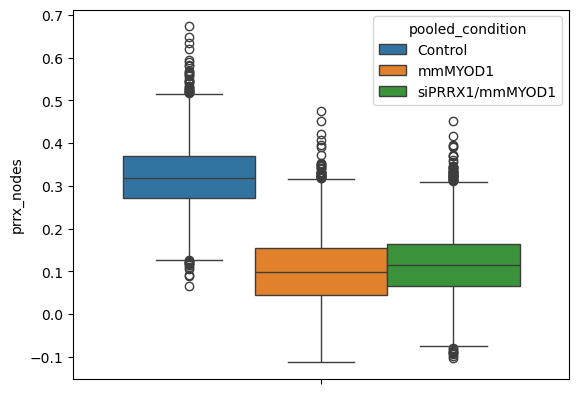

In [45]:
sc.tl.score_genes(
    fdata,
    gene_list=prrx_genes_robust,
    ctrl_size=len(prrx_genes_robust),
    score_name='prrx_nodes',
    layer='log_norm',
)

tmp = fdata.obs[['pooled_condition', 'prrx_nodes']].copy()
tmp.head()

display(tmp.groupby('pooled_condition', observed=True)['prrx_nodes'].describe())

sns.boxplot(
    data=tmp,
    y='prrx_nodes',
    hue='pooled_condition',
)

plt.show()

computing score 'myod_nodes'
    finished (0:00:01)


,count,mean,std,min,25%,50%,75%,max
pooled_condition,,,,,,,,
Control,6902.0,0.208352,0.031068,0.099467,0.187741,0.208065,0.229031,0.331071
mmMYOD1,2255.0,0.187393,0.040418,0.046035,0.160671,0.187710,0.214806,0.333890
siPRRX1/mmMYOD1,3456.0,0.182616,0.035148,0.028495,0.160214,0.182193,0.205600,0.356030


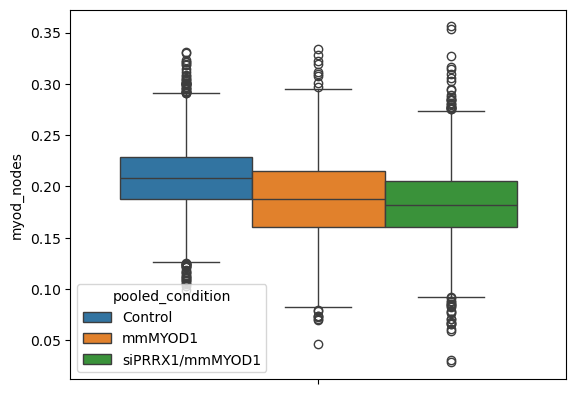

In [46]:
sc.tl.score_genes(
    fdata,
    gene_list=myod_genes_robust,
    ctrl_size=len(myod_genes_robust),
    score_name='myod_nodes',
    layer='log_norm',
)

tmp = fdata.obs[['pooled_condition', 'myod_nodes']].copy()
tmp.head()

display(tmp.groupby('pooled_condition', observed=True)['myod_nodes'].describe())

sns.boxplot(
    data=tmp,
    y='myod_nodes',
    hue='pooled_condition',
)

plt.show()